In [12]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import yaml

# Load data

In [75]:
def load_segments(yaml_path):
    with open(yaml_path) as stream:
        try:
            res = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            res = None
    return res

In [76]:
segments1 = load_segments("/Users/bapti/Projets/REDEV/ML_walkability/data/P01/segments_P01.yaml")
segments2 = load_segments("/Users/bapti/Projets/REDEV/ML_walkability/data/P02/segments_P02.yaml")

In [98]:
video1 = "/Users/bapti/Projets/REDEV/ML_walkability/data/P01/raw/Video.mp4"
video2 = "/Users/bapti/Projets/REDEV/ML_walkability/data/P02/raw/Video.mp4"

cap1 = cv2.VideoCapture(video1)
cap2 = cv2.VideoCapture(video2)

os.path.exists(video1)

True

# Video manipulation

In [97]:
def read_frame(cap, time_s):
    """Lit une frame spécifique (en secondes) depuis une vidéo."""
    cap.set(cv2.CAP_PROP_POS_MSEC, time_s * 1000)
    ret, frame = cap.read()
    if not ret:
        return None
    frame = cv2.resize(frame, (320, 180))  # petite taille = plus rapide
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray

def video_duration(cap):
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps
    return duration

In [ ]:
def score_similarity(ref_image, list_images):
    scores = []
    for frame in list_images:
        score = ssim(ref_image, frame).item()
        scores.append(score)
    return scores

In [100]:
video_duration(cap1), video_duration(cap2)

(374.43719999999996, 370.95120000000003)

# First search test

In [ ]:
times = np.linspace(0, 120, 500)
list_images = [read_frame(cap2, t) for t in times]

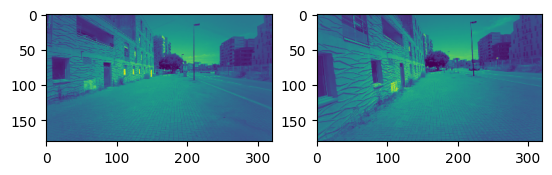

In [62]:
ref = read_frame(cap2, 60)
test = read_frame(cap1, 59)

plt.subplot(121)
plt.imshow(ref)
plt.subplot(122)
plt.imshow(test)

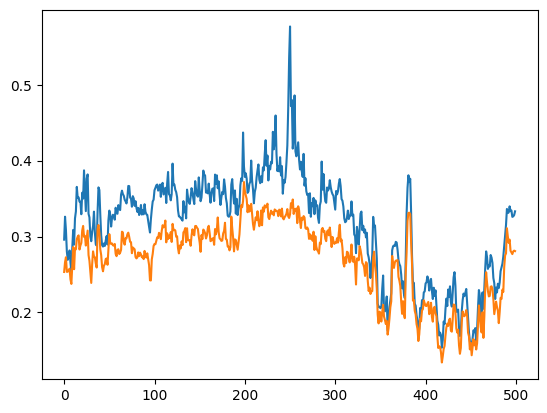

In [63]:
ref_scores = score_similarity(ref, list_images)
test_scores = score_similarity(test, list_images)

plt.plot(ref_scores)
plt.plot(test_scores)

In [57]:
test_scores = np.array(test_scores)
window = 15
windows = np.lib.stride_tricks.sliding_window_view(test_scores, window)
rolling_median = np.median(windows, axis=1)
rolling_median = np.concatenate(([0] * (window - 1), rolling_median))

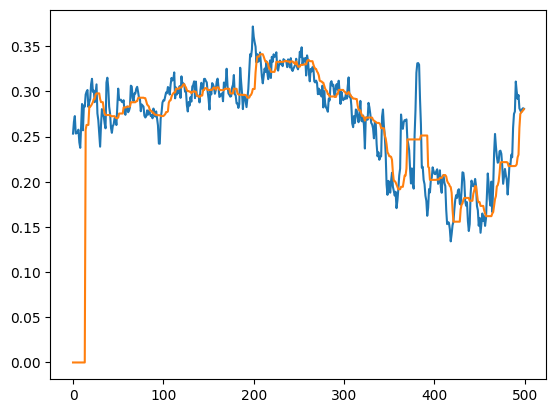

In [58]:
plt.plot(test_scores)
plt.plot(rolling_median)

In [82]:
best_by_median = max(range(len(rolling_median)), key=lambda x: rolling_median[x])
best_time = times[best_by_median]
delta = 2
precise_times = np.linspace(best_time-delta, best_time+delta, 2*delta*10)
precise_list_images = [read_frame(cap2, t) for t in precise_times]

In [83]:
precise_test_scores = score_similarity(test, precise_list_images)

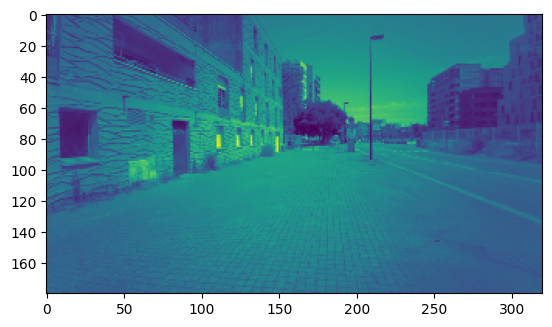

In [84]:
plt.imshow(ref)

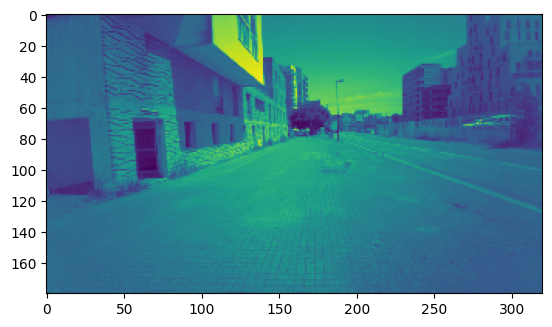

In [85]:
best = max(range(len(precise_test_scores)), key=lambda x: precise_test_scores[x])
plt.imshow(precise_list_images[best])

# Sync function

In [110]:
video = cap2
image = test
times = np.linspace(0, video_duration(video), int(video_duration(video) / 2))
list_images = [read_frame(video, t) for t in times]
list_images = [im for im in list_images if im is not None]

In [111]:
test_scores = score_similarity(image, list_images)

In [112]:

test_scores = np.array(test_scores)
window = 15
windows = np.lib.stride_tricks.sliding_window_view(test_scores, window)
rolling_median = np.median(windows, axis=1)
rolling_median = np.concatenate(([0] * (window - 1), rolling_median))
best_by_median = max(range(len(rolling_median)), key=lambda x: rolling_median[x])
best_time = times[best_by_median]
delta = 2
precise_times = np.linspace(best_time-delta, best_time+delta, 2*delta*10)
precise_list_images = [read_frame(video, t) for t in precise_times]
precise_test_scores = score_similarity(test, precise_list_images)
best = max(range(len(precise_test_scores)), key=lambda x: precise_test_scores[x])

In [160]:
def find_image_time_in_video(image, video):
    times = np.linspace(0, video_duration(video), int(video_duration(video) * 2))
    list_images = [read_frame(video, t) for t in times]
    list_images = [im for im in list_images if im is not None]
    test_scores = score_similarity(image, list_images)
    test_scores = np.array(test_scores)
    window = 15
    windows = np.lib.stride_tricks.sliding_window_view(test_scores, window)
    rolling_median = np.median(windows, axis=1)
    rolling_median = np.concatenate(([0] * (window - 1), rolling_median))
    best_by_median = max(range(len(rolling_median)), key=lambda x: rolling_median[x])
    best_time = times[best_by_median]
    delta = 2
    precise_times = np.linspace(best_time-delta, best_time+delta, 2*delta*10)
    precise_list_images = [read_frame(video, t) for t in precise_times]
    precise_list_images = [im for im in precise_list_images if im is not None]
    precise_test_scores = score_similarity(test, precise_list_images)
    best = max(range(len(precise_test_scores)), key=lambda x: precise_test_scores[x])
    return precise_times[best].item()

In [114]:
find_image_time_in_video(test, cap2)

np.float64(54.08754173250174)

In [167]:
def timecode_to_seconds(timecode):
    timecode = timecode.split(':')
    return int(timecode[0])*3600+int(timecode[1])*60+int(timecode[2])

def find_segments_in_video(
        video_path_ref,
        video_path_target,
        segments_ref,
    ):
    ref = cv2.VideoCapture(video_path_ref)
    target = cv2.VideoCapture(video_path_target)
    target_times = dict(segment1=0)
    for segment in segments_ref['segments'][1:]:
        start_time_ref = segment['start_time']
        start_time_ref = timecode_to_seconds(start_time_ref)
        start_image_ref = read_frame(ref, start_time_ref)
        start_time_target = find_image_time_in_video(start_image_ref, target)
        target_times[f'segment{segment['segment_id']}'] = start_time_target
    return target_times

In [168]:
res = find_segments_in_video(video1, video2, segments1)

In [169]:
res

{'segment1': 0,
 'segment2': 122.36492097020098,
 'segment3': 192.51027240471242,
 'segment4': 207.686003991684,
 'segment5': 155.02796620928623}

In [170]:
segref = {f'segment{x['segment_id']}': timecode_to_seconds(x['start_time']) for x in segments1['segments']}

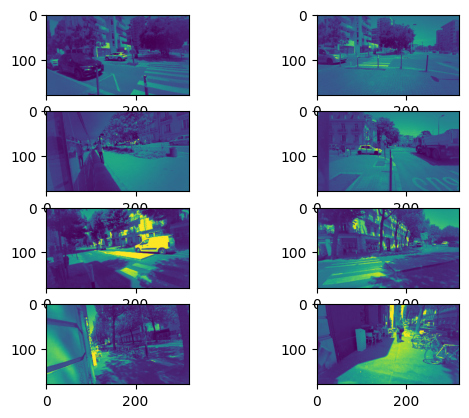

In [172]:
for i in range(4):
    ref = read_frame(cap1, segref[f'segment{i+2}'])
    found = read_frame(cap2, segref[f'segment{i+2}'])
    plt.subplot(4, 2, 1+i*2)
    plt.imshow(ref)
    plt.subplot(4, 2, 2+i*2)
    plt.imshow(found)
plt.show()